# Tutorial: Getting Started with Containers

This tutorial covers the basics of how to use containers to deploy software on the OSPool.

## Setup

1. Login to [osg-htc.org/notebooks](https://osg-htc.org/notebooks).
2. Launch the "Guest" notebook option.
3. Navigate to the directory `tutorial-containers`.
4. Open the notebook `tutorial-containers.ipynb`.
5. Follow the instructions in the notebook.

## Materials

* Slides: TBD
* Notebook: [tutorial-containers.ipynb](/tutorial-containers.ipynb)
* GitHub: [github.com/osg-htc/tutorial-containers](https://github.com/osg-htc/tutorial-containers.git)

## Disclaimer

The content of this training represents the practical, cumulative hands-on experience of someone who 

* does not have a background in computer science
* is not a professional programmer
* is not a developer of container technologies

As such, there may be inaccuracies in technical details and mental models of containers, their functionality, and their implementation.

# Quickstart: The Power of Containers

A short hands-on exercise demonstrating how containers can be useful.

Let's say that you need to use Python 3.10 for your research program.

First, check the version of Python available in the OSPool Notebook:

In [ ]:
python3 --version

You should see Python 3.13.

Next, let's "build" a container.
For now, just run the provided commands - we'll discuss what each one is doing later in the training.

In [ ]:
apptainer build python310.sif docker://python:3.10

(There may be a lot of lines due to the progress bars.)

When it is done, there is a new file `python310.sif`:

In [ ]:
ls -lh python310.sif

Now that you have the `.sif` file of the container, you can use it as an execution environment for commands and scripts.

Let's see what version of Python is available in this container:

In [ ]:
apptainer exec python310.sif python3 --version

It's Python 3.10!

This example is overly simplified, and there are a lot more details and caveats involved, but..

The takeaway is: **Containers are portable, reproducible software environments that you control.**

# Core Concepts

A simplified mental model for working with containers

There are some **core concepts** that you should know to work with containers.
Under the hood, containers are a fairly complicated piece of technology. 
But like with driving a car, you don't need to know how the engine works in order to get around town.

We'll start with an analogy to "movies".

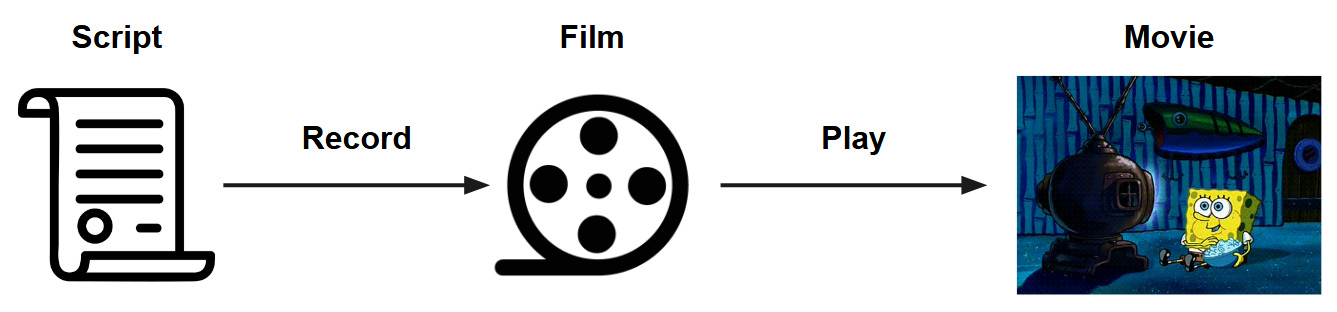

1. A **movie** is the sequence of images and sounds that you watch on the screen.
2. To watch a movie, you have to **run** or **play** it.
3. The **film** or other physical media stores the movie and is portable to other compatible devices.
4. To create a movie, you have to **build** or **record** the film.
   * If you want to make small changes to an existing movie, you can edit an existing film.
   * If you want to make major changes, you should record a new film.
5. A **script** is used to organize the events and scenes to be recorded on film for creating the movie.

This description of a movie is analogous to how containers work.

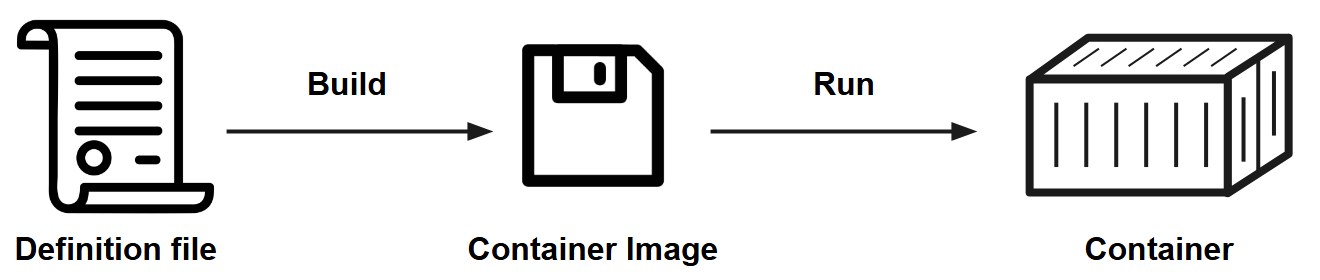

1. A **container** is the active environment that you can interact with.
2. To interact with a container, you must first **run** or **launch** it.
3. The **container image** stores the container and is portable to other compatible devices.
4. To create a container, you have to **build** the container image.
   * If you want to make small changes to an existing container image, you can "edit" it.
   * If you want to make major changes, you should build a new container image.
5. A **definition file** is used to organize the software and environment details for the build process.

> In the same way that the word **movie** can be used to refer to the physical media (the **film**, DVD, etc.) or the sequence of images on the screen,
> so too can the word **container** be used to refer to the **container image** or the actively running environment.

Some other things to note:

* **You can easily build a new container on top of an existing container**, adding software and functionality that was not present in the original container.
You could perhaps think of this as creating a custom "extended cut" version of a movie.
* **The software installation commands are only executed when the container is built.** The installation commands are not rerun each time you launch the container. This is just like how a movie is not re-recorded each time you press "play".
* **Containers built on one type of machine (MacOS with ARM chip) may not work on other types of machines (Linux with x86_64 chip)**, like trying to play a Blu-ray disc in a regular DVD player. There are ways to convert between "formats" though.

**How does this relate to the quickstart?**

First, you built a new container image (`python310.sif`).
Then, you launched the container in order to run the version command.

> You didn't write a "definition file" in this case because you were effectively copying an existing container image (`docker://python:3.10`).



# Lifecycle for Deploying Software in Containers

An overview of the step-by-step process of working with containers.

The process of deploying software in containers follows this general sequence. 
More details for each step are provided in later sections.

1. **Identify the "main" software you want to deploy.**
2. **Check the instructions for installing the software you want to deploy.**
   * Are there additional programs required in order for the software to work?
   * Is there a "major" platform you can use to install the software (e.g., `pip`, `conda`, `cran`)
3. **Find a good "base" container image to use as a starting point**
   * A good rule is that the "base" container image should already include the most-difficult-to-install software that you need
   * **Note**: some developers publish official container images for their software!
4. **Write a definition file, containing the installation commands for the software you want**
5. **Build the container image**
   * There are commonly issues with this step! Make changes to the definition file that address the error message you get.
6. **Test that the software in the container image works as expected**
   * A "successful" build doesn't mean the software is working!
7. **Distribute the container image where it needs to go**
8. **Use the container image**

**Once you have a working container (after step 6), then in principle you never have to repeat this process!**
If you do want to make changes, the best action in terms of reproducibility is to go back to step 4 to edit the definition file and repeat the following steps.

**Deploying your software in a container is no more difficult than any other methods of deploying your software!**
Even if you don't use a container, you'll still need to learn how to install your software program, and installing software is hard, period.

**By using a container, you also get:**

* a **reproducible** environment
* **control** over the libraries and other programs you want to install
* simple deployment **separate** from the host operating system

# Example: A More Realistic Python Container

A hands-on exercise for a practical example involving Python.

You are starting a new computational research project and have identified the "main" software that you want to deploy.

The program is a collection of scripts in a GitHub repository.
The README states that is requires `python` v3.10, as well as the Python packages `numpy` (v1.26) and `scipy`.
They provide some commands to run that *should* fulfill the requirements:

```
sudo apt-get install python3 python3-pip
pip install numpy scipy
```

For your own purposes, you also want to use the Python package `seaborn`. 

**How should you proceed?**

## What do you need?

First, list out what you need. 

For the above scenario, you need:

* python v3.10
* python packages:
    * numpy v1.26
    * scipy
    * seaborn

## A good starting point

Choosing a good base image can save a lot of time.

Considering the software requirements, if you are able to get `python` set up, then you should be able to use the `pip` command to install additional Python packages.

In this case, **a good base container would come with `python` v3.10 already installed.**

For information on how to find an official container, see the "Finding container images" section in Appendix B at the end of this notebook.
**TL;DR: you want to use `docker://python:3.10` as the base image for your container.**

## Writing the definition file

*The exact format of the definition file depends on the container technology that you are using.*

We are focusing on the [Apptainer](https://apptainer.org/) container program, which is open source and designed for shared computing systems (and arguably more beginner friendly).

A simple Apptainer definition file has the following format:

```
Bootstrap: docker
From: <reponame>/<imagename>:<tagname>

%post
    # software installation commands
```

Here is what each line is doing:

1. `Bootstrap: docker` - this tells Apptainer to use a Docker container as a base image.
2. `From:` - this tells Apptainer the address of the container image. When the `Bootstrap` is set to `docker`, this corresponds to the address on DockerHub, by default.
3. Empty line - purely for aesthetics
4. `%post` - this tells Apptainer that the following lines are the commands to run during the container "build".
5. A comment - this will be ignored. Also note that the leading indent is optional.

> There are more sections (denoted by a leading `%`) for triggering different features, but this simple example works for 90% of users.
> See the [Apptainer documentation](https://apptainer.org/docs/user/latest/definition_files.html) for more information.

> The tech industry has largely adopted [Docker](https://www.docker.com/) (which is where the "Docker" in "DockerHub" comes from), but it is a commercial technology intended for enterprise systems and personal computers.
> Conveniently, you can convert a container image from the Docker format to the Apptainer format (it is more difficult to do the reverse).

**Create a new file called `my-container.def` with the following contents:**

```
Bootstrap: docker
From: python:3.10

%post
    python3 -m pip install numpy==1.26 scipy seaborn
```

Make sure to save the file!

> Note: you do not need to use `sudo` for the installation commands in the `%post` section!

Run the following command and confirm the contents are the same:

In [ ]:
cat my-container.def

## Build the container

At this point, you've written the script for the movie.
Now you need to record it to film.

To build an Apptainer container, you use the command

```
apptainer build <desired_name> <definition_file>
```

* The first argument is the filename you want the container image to have
* The second argument provides the instructions for building the container image (the definition file)

For our example, that means the command to run is

```
apptainer build my-container.sif my-container.def
```

Build the container by running that command:

In [ ]:
apptainer build my-container.sif my-container.def

You will say a lot of output here, mostly because progress bars don't render "normally" in a Jupyter notebook.

**First, Apptainer downloads the base container from DockerHub.**
This involves multiple files and extractions - you don't need to worry much about what is happening here.

**Next, Apptainer starts running the commands that you provided in the `%post` section of the definition file.**
This section is separated from the previous by the `INFO: Running post scriptlet` line. 
If you are familiar with `pip install` commands, the output is the almost exactly the same as usual!

> When building a container, you can ignore the warning from pip about running as 'root'.
> You should totally heed that warning if you aren't building a container!

**Finally, once the `%post` commands have all run (typically "successfully"), Apptainer records the results as a `SIF` formatted file.**
The process is complete once you see `Build complete`.

> In the quickstart, the middle step was skipped

Confirm that the container image has been created by running:

In [ ]:
file my-container.sif

## Test/use the container

It's always good practice to review the final product. 

You can execute commands one at a time using the `apptainer exec` command, which is what we used in the Quickstart section.
The syntax is

```
apptainer exec <image_name> <command_to_run>
```

In general, if you can "import" a package or print the program's help text, that means the program has been successfully installed.
(But whether it does what you want is a separate question!)

Run the following command to check that the desired packages have been installed:

In [ ]:
apptainer exec my-container.sif python3 -c 'import numpy, scipy, seaborn; print("numpy =",numpy.__version__); print("scipy =",scipy.__version__); print("seaborn =",seaborn.__version__)'

You should see 

```
numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2
```

For more involved tests or commands, it's better to write a short script with the commands you want to use and then execute them inside the container.

To see this in practice, create a file called `python-test.py` with the following contents:

```python
import numpy, scipy, seaborn, sys

print(f"""
python = {'.'.join(map(str, sys.version_info))}
numpy = {numpy.__version__}
scipy = {scipy.__version__}
seaborn = {seaborn.__version__}
""")
```

(we've also added a line to check the version of Python)

Then run the following command:

In [ ]:
apptainer exec my-container.sif python3 python-test.py

To run commands in the container environment interactively, you can use the `shell` command:

```
apptainer shell my-container.sif
```

This doesn't work well in Jupyter notebooks, however.
To try it, first open a new "terminal" tab in the Jupyter notebook.
Then run the `apptainer shell my-container.sif` command.

The commands you run will be executed in the container environment.
When you are done, enter

```
exit
```

to exit the interactive shell mode.

***Do not evaluate any notebook cells while the `apptainer shell` is active!***
Jupyter and `apptainer shell` don't play well together and you may get weird errors otherwise!

## Putting scripts in the container

How should you get those scripts into the container image?

In the initial scenario, we proposed that you are a researcher trying to use some scripts in a GitHub repository.
How should you handle these scripts?

First, you have to answer this question: when should the scripts be placed inside the container image?

1. During the build phase
2. During the execution phase

### Adding scripts during the build phase

**This option is for "mature" programs** - that is, something that you don't plan to modify after the build phase is complete and the container image has been created. 
Maybe you'll make changes, but you can plan on repeating the build phase to create a new container image in that case.

To add files to the container build, you can use the `%files` section of the definition file, as described [here](https://apptainer.org/docs/user/latest/definition_files.html#files). (This is specific to Apptainer, but other container technologies have an analogous method; the specific syntax varies.)

If the files are publically available, you can also just do a `git clone`, `wget`, or some other download command to fetch the files during the build phase.

### Adding scripts during the execution phase

**This option is best for "developing" programs** - that is, something that you are actively developing. Because you are frequently making changes to the scripts, you want to skip the build phase as much as possible.

* **If you are submitting jobs to the OSPool**, scripts included in the `transfer_input_files` line of your submit file will be automatically added to the container at the run time of the job.
* **If you are manually launching the container**, you should check out the "Appendix A: Containers and the filesystem" section at the end of this document.

# Containers on the OSPool

Distributed computing with containers in mind.

**The OSPool is a distributed computing resource that is available for free to all U.S.-based researchers.**

* [Overview of the OSPool](https://osg-htc.org/services/ospool)
* [Getting started on the OSPool](https://portal.osg-htc.org/documentation/overview/account_setup/is-it-for-you/)

Since the computer resources are geographically distributed across the U.S., data distribution can be a challenge.
**Containers and other re-usable data can be "cached" in various places using the Open Science Data Federation (OSDF).**
All OSPool users have a personal directory accessible via the OSDF.
Non-OSPool users can also access public data in the OSDF and can work with the team to set up authenticated access.

* [Overview of the OSDF](https://osg-htc.org/services/osdf)
* [Public data in the OSDF](https://osg-htc.org/services/osdf/data)
* [OSDF documentation for OSPool users](https://portal.osg-htc.org/documentation/htc_workloads/managing_data/osdf/)
* [OSDF documentation for non-OSPool users](https://docs.osdf.osg-htc.org/)

The software HTCondor ([htcondor.org](https://htcondor.org)) is used to run the OSPool, and HTCondor comes with built-in container support.
In principle, all you need to do is add the following line to your submit file:

```
container_image = osdf:///location/of/container/image.sif
```

**The use of Apptainer images is well supported on the OSPool.**

> While HTCondor has good support for Docker images as well, most computing capacity accessible via the OSPool does not use Docker.

## Simple Python Job

We've provided some example "submit files" for describing an HTCondor job. 

### Without a container

The first example does not use a container:

In [ ]:
cat no-container.sub

For now, we won't worry about the details of the submit file.
(See the OSPool documentation at [portal.osg-htc.org](https://portal.osg-htc.org).)

You can submit this test job by running `condor_submit <submit_file>.sub`.

In [ ]:
condor_submit no-container.sub

You can check the status of your jobs by running the command `condor_q`. 
This gives a snapshot of **currently active or pending** jobs.
If the job disappears from this list, then it has completed or you have removed it.

In [ ]:
condor_q

> If using a normal terminal (i.e., not a Jupyter Notebook), then you can use the command `condor_watch_q` to monitor the live progress of your jobs.

When completed, you should see the new files `no-container.out` and `no-container.err`. (The `no-container.log` file is created immediately on submission and is HTCondor's record of its management of your job.)

Let's see what they contain:

In [ ]:
cat no-container.out

In [ ]:
cat no-container.err

You should hopefully see the package versions in the `.out` file and nothing in the `.err` file.

### With container

As before, we want to ensure that our desired packages are installed and have the right versions.

In the second example, we've added the `container_image` line to specify the Apptainer image we want to use.
(We also changed the names of the files we are generating to match the name of the submit file.)

Let's take a look:

In [ ]:
cat with-container.sub

Like before, submit this job using `condor_submit`.

> NOTE: **If you are not using the "Guest" option** of the OSPool Notebook, you should not submit more than 1 or 2 jobs using this approach!
> You should instead follow the instructions for using the OSDF with containers, described [here](https://portal.osg-htc.org/documentation/htc_workloads/managing_data/osdf/).

In [ ]:
condor_submit with-container.sub

When complete, check the contents of the new files:

In [ ]:
cat with-container.out

In [ ]:
cat with-container.err

You should see that the version of packages matches what you get when you run the python script directly in the container:

In [ ]:
apptainer exec my-container.sif python3 python-test.py

## OSG Container Support

### Curated containers

We maintain a set of container images for a handful of common softwares for use on the OSPool with a variety of "nice to have" packages/libraries.

The containers are available via a Docker-compatible repository at `hub.opensciencegrid.org`.
**For a list of available containers, see [this documentation page](https://portal.osg-htc.org/documentation/htc_workloads/using_software/available-containers-list/).**

For example, the list has an entry for a "Rocky Linux 9" base image, available at `htc/rocky:9`. 
To use this image in your definition file, you would use the header

```
Bootstrap: docker
From: hub.opensciencegrid.org/htc/rocky:9
```

You can also use the address `docker://hub.opensciencegrid.org/htc/rocky:9` with your preferred container technology to pull the image.

> If you are curious about what software we include in these curated containers, you can find the corresponding definition file in our GitHub repository at [github.com/osg-htc/htc-images](https://github.com/osg-htc/htc-images).
> For example, the aforementioned Rocky 9 image uses [this (Docker) definition file](https://github.com/osg-htc/htc-images/blob/main/htc/rocky%3A9/Dockerfile).

### Efficient distribution with the OSDF

Container images are usually a couple of gigabytes in size. For most computers and networks, downloading that much data once is usually no big deal.
But the OSPool is a geographically distributed system that executes an **average of 1 million jobs per day**. 
If every job uses a container, that would be **petabytes** of data transferred over the nation's internet! (Not to mention all the other input, output data that is needed!)

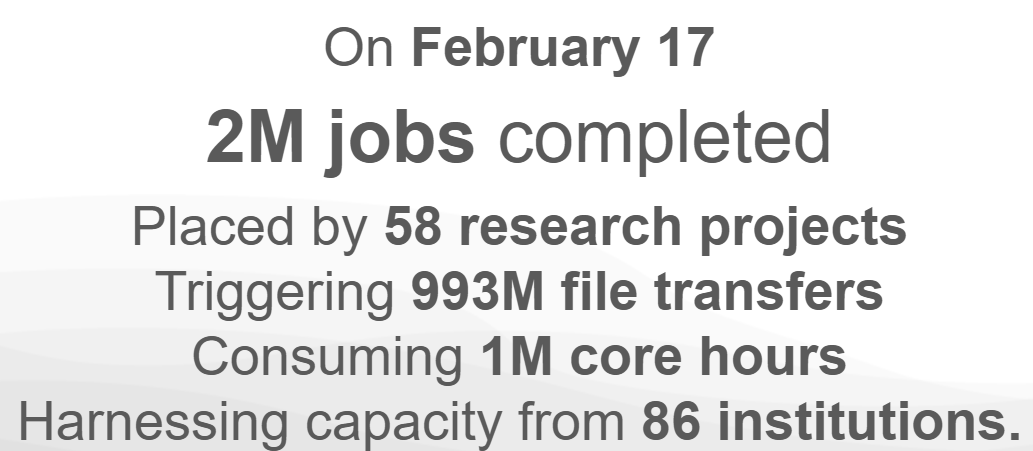

To help prevent overloading the networks of contributing institutions, the OSG operates the Open Science Data Federation (OSDF).
The OSDF is a system of robust caches at major internet hubs.
When a file is transferred through the OSDF, a copy is kept at a nearby cache.
The next time that file is requested through the OSDF, the cache can provide it's copy instead of going back to the "origin" of the data.

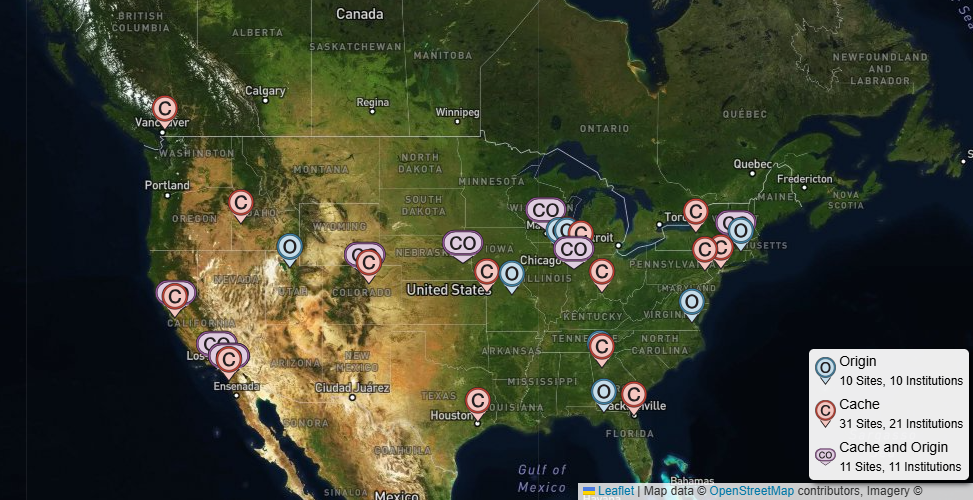

**All OSPool users have access to an OSDF origin through their main access point.** 
By placing their container image in the OSDF origin and using the corresponding syntax in their submit file, they can harness this caching system for their OSPool jobs. 
For instructions on how to do so, [see this guide](https://portal.osg-htc.org/documentation/htc_workloads/managing_data/osdf/). 

**The OSDF is used for more than just the OSPool, though.**
A variety of [public datasets](https://osg-htc.org/services/osdf/data) are accessible through the OSDF, with more being added all the time.

* If you are interested in accessing data via the OSDF but not while using the OSPool, [see this documentation](https://docs.osdf.osg-htc.org/).
* If you are interested in making your data accessible via the OSDF, [see the overview page](https://osg-htc.org/services/osdf).

# Next Steps

### Build your own container

Now that you've learned the basics, you should try building a container for **your** software!
Appendix B below has more tips for building containers; you should check out the "Example definition files" for sure!

### Using your own container

#### ...on the OSPool

If want to use the OSPool for your work, be sure to check out the guides at [portal.osg-htc.org](https://portal.osg-htc.org), particularly the ones linked earlier in this notebook.

If you don't have an OSPool account, **you can request an OSPool account** through [this form](https://portal.osg-htc.org/application).

#### ...on your computer

Apptainer works best on a Linux operating system. The simplest way to get started is to set up the "unprivileged" installation, [described here](https://apptainer.org/docs/admin/1.4/installation.html#install-unprivileged-from-pre-built-binaries).

In this case, you should also check out Appendix A below to understand how containers interact with your local filesystem.

> You can install other container technologies instead. 
> The most common commercial technology is Docker Desktop.
> But while generally convenvient to use, it is a licensed software that requires purchase for most use cases.

#### ...on your local cluster

**For just your user account**, you can set up the "unprivileged" installation of Apptainer on your local system, [as described here](https://apptainer.org/docs/admin/1.4/installation.html#install-unprivileged-from-pre-built-binaries).

**For all users**, you should ask the system administrator to set it up. Apptainer even provides a [template](https://apptainer.org/docs/user/latest/quick_start.html#installation-request) for making such a request. 

It may be possible for your system administrator to set up other container technologies on the cluster, but there may be additional security concerns to consider. (Apptainer was designed to be deployed on shared computing resources; other technologies, not so much.)

> Note: On HPC systems, most containers should work just fine when executed on a **single node**.
> If you want to use a container for executing a calculation across **multiple nodes**, however, your container has to be set up to work with that cluster's network hardware.
> It is possible, but can be challenging to get right.

### Get help

For support, **you can email `support@osg-htc.org`.**

**We also have twice weekly office hours**, online on Zoom, for OSPool users every Tuesday and Thursday. [Details here](https://portal.osg-htc.org/documentation/support_and_training/support/getting-help-from-RCFs/).

**We host monthly trainings** for OSPool users and have past materials available online.

* [Current training schedule](https://osg-htc.org/services/facilitation/monthly-training)
* [Past materials](https://portal.osg-htc.org/documentation/support_and_training/training/materials/)

### Connect with the OSG

**We host weekly campus meetups** targeted at campuses who are interested in, or actively contributing to, the OSPool. For more information, see the [contributors documentation here](https://osg-htc.org/campus-docs/).

**We host a weeklong "OSG School" over the summer**, where participants learn more about high throughput computing on the OSPool. **Applications are now open** for this year, in Madison, WI, from July 13-17. More information at [osg-htc.org/school-2026](https://osg-htc.org/school-2026/).

**We host an annual conference on high throughput computing.** This year is **HTC26**, from June 9-12 in Madison, WI. Agenda is still being planned out. See the [save-the-date announcement](https://osg-htc.org/events/2026/06/09/throughput-computing-week/) for more information. Last year's conference website is [here](https://agenda.hep.wisc.edu/event/2297/).

# Appendix A: Containers and the Filesystem

Things start to get complicated when input and output files are involved.

When a container is launched, it is separated from the rest of the computer.
This usually includes the filesystem.
If you try to access a "higher" level directory from inside of the container, you may "see" a different set of files.

Apptainer has default behavior to make a bridge between the host system and the container environment.
Understanding that bridge will help us understand how we can make changes to the way the container interacts with the host.

### Accessing files from inside the container

Let's start by running this command on the host and inside of the container:

In [ ]:
echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"

The command shows the current directory (`PWD`), its contents, the home directory (`HOME`), and its contents.

Now let's run it inside of the container:

In [ ]:
apptainer exec my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

The two executions have the same output - this is because Apptainer's default "bridge" is in place to make it easier to work with the container environment.

> The `bash -c ''` part is necessary in order to make sure the shell variables `$PWD` and `$HOME` are evaulated inside of the container environment, and not in the host environment.

We can disable Apptainer's default "bridge" by using the `--contain` option.
Let's see what happens this time:

In [ ]:
apptainer exec --contain my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

Some things have changed: 

* the current directory (`PWD`) is now the same as the home directory
* the home directory (`HOME`) is empty (!)

So (among other things), Apptainer's defaults make it so that the current directory (and its contents) on the host are accessible inside of the container environment, and that the home directory (and its contents) on the host is as well.

We can manually recreate the bridge. To do so, we'll need to use the `--bind` and `--cwd` options:

* `--bind <location_in_host>:<location_in_container>` - this option maps a directory on the host system to a location of your choice inside of the container.
* `--cwd <location_in_container>` - this options says where inside the container the command should be executed.

First, let's add in the current directory. We can use `--bind $PWD:$PWD` to do so (because when we run the `apptainer exec` command, the `PWD` environment variable is set to the host's value).
We'll also need to use `--cwd` to change the value of `PWD` inside of the container:

In [ ]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

Now we see what we expected to see for the current directory.

Note that we see **only** the `tutorial-containers` directory inside of the home directory - that is because that is the only part of the host filesystem that we told Apptainer to make available inside the container.

If we want to see all of the host home directory inside the container, we can bind that in as well:

In [ ]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD --bind $HOME:$HOME my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

In this case, we again see the contents of the home directory.

> Since the `PWD` directory is inside of the `HOME` directory tree, we technically only needed to use one `--bind`  option: `--bind $HOME:$HOME`.

While in practice this combination of `--contain` and `--bind` effectively cancel each other out, the point is that **with the `--bind` option you can specify what part of the host filesystem your container has access to**.

### "Saving" changes

IMPORTANTLY: **only files created in a "mounted" (`--bind`) directory will be kept after the container stops running!!**

To demonstrate this, we'll first make a script as follows:

In [ ]:
cat << EOF > create_directory_and_file.sh
mkdir -p ~/test_directory
touch ~/test_directory/example.txt
echo "Created \$(ls ~/test_directory/example.txt)"
EOF

chmod +x create_directory_and_file.sh

This script will create a new directory `test_directory` and create a new file in that directory, called `example.txt`, and then confirm that the file exists at the time of the script execution. 

First, let's execute try executing this script in the container using the `--contain` option but no `--bind` mounting:

In [ ]:
apptainer exec --contain my-container.sif bash create_directory_and_file.sh

This fails, because inside of the container there is no such script.

We need to add in the `PWD` binding we did earlier:

In [ ]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash create_directory_and_file.sh

That appears to have worked as expected.

Let's check if it exists after the container has stopped running:

In [ ]:
ls ~/test_directory/example.txt
ls -ld ~/test_directory

Nope!

If we want the changes to persist, we'll need to either mount the parent directory (`HOME`) into the container, or else copy the files to a part that is mounted.
Either of these should work:

```bash
apptainer exec --contain --bind $HOME:$HOME --cwd $PWD my-container.sif bash create_directory_and_file.sh
# OR
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash -c 'bash create_directory_and_file.sh && cp ~/test_directory/example.txt ./'
```

The first example is probably the "simplest" conceptually, but it does give the container and the script access to your entire home directory (!). 
The second example protects your home directory, but is more complex.

The best approach to address this situation, in practice, is to modify the main script (here, `create_directory_and_file.sh`) to operate at or below the execution directory.
That is, instead of `mkdir -p ~/test_directory` the script should do `mkdir -p ./test_directory`. 

### Containers are immutable

Another important item to note is that **most locations "in" the container image are read-only**.

For example, let's try to create a file in the root directory:

In [ ]:
apptainer exec --contain my-container.sif bash -c 'touch /my-new-file.txt'

In [ ]:
apptainer exec my-container.sif bash -c 'touch /my-new-file.txt'

The root directory (`/`) and some of it's immediate subdirectories cannot by `--bind` mounted into the container - these directories are needed by the container in order to function!
And depending on how your administrator configured the Apptainer installation, there may be other locations that this applies to.

Sometimes, a program will try to write files into the root directory. There are generally two cases:

1. The program is trying to use a default location that evaulates to a read-only location.
2. The program is trying to use a specific absolute path.

The most common occurence of (1) is that during installation, the program used the value of `HOME` to be the root directory (`/`). This problem can be usually resolved by including a `export HOME=<value>` statement with `<value>` replaced by a mounted location in the container. Some programs may have more specific settings to manipulate, such as a "cache" location or some other setting. Digging into the documentation usually reveals the setting you should change.

There are two main causes of (2): (a) your script uses absolute paths or (b) you are using a container specifically written for Docker.

* (a): Often researchers who write their own programs start on their personal computer. To stay organized, they have some code that says all outputs should go into a directory like `/User/Documents/Research/Project3/outputs`, while maybe the script itself lives in `/User/Programs/my_code.py`. To work in containers (and shared computing systems), the researcher should modify their code to work with relative paths instead.
* (b) The "normal" installation of Docker does allow some writing in the root directory (`/`), so some developers will use paths like `/data` or `/app` for writing temporary files. Sometimes the "official" container you are using follows this paradigm. You may be able to modify the container to work around this issue, but it may be easier to build a new container where you manually install the software yourself.

# Appendix B: Tips for Building Containers

Software installation is hard, regardless of whether or not it's in a container.

## Finding container images

A lot of mainstream softwares (and even niche softwares, depending on the developer) have official containers published on the internet for anyone to use.
In general, most of these containers are published on "DockerHub", which is kind of like "GitHub", but for container images.
Keep in mind, though, that anyone can publish containers on DockerHub!

When you search for containers on DockerHub, look for images with the labels `Docker Official Image`, `Verified Publisher`, or `Sponsored OSS`.
These will generally be safe to use, but like with anything on the internet, you should do some due diligence to make sure the publishers are legitimate. 

For example, let's try to find a container image that has Python v3.10. 
When you search DockerHub for `python`, you should see a result for a "Docker Official Image". 
Clicking on the result takes you to [this page](https://hub.docker.com/_/python), which lists a lot of information.
You can then look at the `Tags` tab for the particular version of the container you are interested in. 
In this case, if you search "3.10", you'll get 19 pages of results (!). 
But for these foundational softwares, the more "general" tag will usually work. That is, requesting `python:3.10` will automatically grab the latest version of the 3.10 container.

**As a general rule, you should avoid using the `latest` tag!**
This tag is always updated to whatever the most recent version is, which means you won't be able to reproduce the container build in the future!

> Smaller, less "foundational" softwares will have much fewer results that are easier to look through.
> Once you've decided on a version, you want to look for the text `docker pull <reponame>/<imagename>:<tagname>`.
> You can then use the corresponding address `docker://<reponame>/<imagename>:<tagname>` in compatible container technologies to reference that container image.
>
> Because `python` is an official repository, the `<reponame>` and `<imagename>` are combined into one.

## Example definition files

Whether for inspiration, education, or just to copy and paste, example definition files are useful for building containers.

Most open source softwares that publish official containers will also provide the original definition file they used for build the container. 
Note, however, that these builds may be highly optimized and therefore difficult to replicate (or even understand!). 

For more beginner friendly examples of container definition files, check out these sources:

**OSPool documentation**

* [Python example](https://portal.osg-htc.org/documentation/software_examples/python/manage-python-packages/#running-python-jobs-that-use-additional-packages)
* [R example](https://portal.osg-htc.org/documentation/software_examples/r/tutorial-R-addlibSNA/#create-a-custom-container-with-r-packages)
* [Julia example](https://portal.osg-htc.org/documentation/software_examples/other_languages_tools/julia-on-osg/#option-1-build-a-container)

**CHTC Recipes**

Example containers are curated in the [CHTC Recipes GitHub repository](https://github.com/CHTC/recipes/software).
While there are some specific to the CHTC system (particularly the ones involving licensed software), most of the examples should be applicable for use on the OSPool.

* [Conda examples](https://github.com/CHTC/recipes/tree/main/software/Conda)
* [PyTorch example](https://github.com/CHTC/recipes/tree/main/software/PyTorch)

**Advanced examples**

For something that looks more like a "traditional" Linux installation of a software, see [this example of installing the software SUMO](https://github.com/CHTC/recipes/blob/main/software/SUMO/sumo.def).

The definition files for the OSG curated images can also be involved - [browse the images repository for examples](https://github.com/osg-htc/htc-images/tree/main/htc).

## Setting PATH

In Linux, except for the most basic commands, every command is just a file in a directory somewhere. 
The `PATH` environment variable stores the list of the directories that should be checked when looking for a command.
When you type a command into the terminal and hit "enter", you are telling the terminal to search the `PATH` locations and execute the first match it finds.
If there are no matches, you'll get a "command not found" error. 

There are some default locations set for the `PATH` variable; you can see them by running `echo $PATH`.
Note that the locations are separated by colons (`:`), and they are searched in order from left to right.

To be able to run a script anywhere as a command, the directory containing the script must be in this `PATH` list. 
You can either (a) move/copy the script into a default location, or (b) update the `PATH` value to include said directory.
Since research software can be location sensitive, it is usually best to update the `PATH` value. 

### Setting PATH at runtime

At anytime, whether or not you are using a container, you can update the `PATH` value to add another location. 
Caution is needed, however, because if you mess it up, you won't be able to run most commands!!
Specifically, you want to **add** a location to the `PATH` value **without removing existing locations**. 

First, save a copy of the previous value with

```
export OLD_PATH="$PATH"
```

This defines a new variable `OLD_PATH` to keep the backup of the value.

If you are adding a location to the `PATH`, you usually want to match the command in that location before any other locations, so you need to prepend the value.
This command will do that, where you should replace `/path/to/new/location` with the desired location.

```
export PATH="/path/to/new/location:$OLD_PATH"
```

If something goes wrong with this command, you can undo the changes by running

```
export PATH="$OLD_PATH"
```

If that doesn't work, exit the terminal and login again.
That will reset the value of `PATH` set during the session.

### Setting PATH during container build

If you know that you will always want to access a command, you can set the value of PATH during the container build.
To do so, you will need to know the absolute path to the necessary location (inside of the container) in advance.
If you're not sure what this path is, it may be easiest to build the container and then test setting the `PATH` as described in the "Setting PATH at runtime" section.

In Apptainer, you specify runtime environment variables in the definition file using the `%environment` section, as in the following example.

```
Bootstrap: docker
From: ubuntu:22.04

%post
    mkdir -p /opt/custom-software
    cp /usr/bin/ls /opt/custom-software/my-ls

%environment
    export PATH="/opt/custom-software:$PATH"
```

When the container is built, it will run the commands in the `%post` section.
The commands in the `%environment` section will be *saved* into the container image.
When you launch the container, the commands that were in the `%environment` section will be executed at startup. 

If you have multiple locations you want to add to the `PATH`, you should declare that in a single `export PATH=` line in the `%environment` section.
Avoid using complicated logic in this section. 
If you need something more complex, you should probably include it as a script in the container and remember to execute it after startup.

## Troubleshooting errors

### Command not found

If the container build is successful, but you get a `command not found` error when you try testing the container, then either

1. the command is not in the list of directories contained by the `PATH` variable, or
2. the installation did not succeed (but the container image was created anyways).

In the first case, you may just need to add the directory containing the command into the `PATH` variable. 
See the previous section `Setting PATH` for instructions.

In the second case, you'll need to look at the build output for error messages, the earlier the better.
Most likely there is a problem with a missing dependency, as covered in a following section.

It could also be that the installation command you are using doesn't install what you want!
For example, there are some Python programs that have one package for using the program directly in Python, but another package for using the program via the command line.
Consult the documentation for the software you are trying to install.

### Build is stuck

Here, the build command is still running but there's been no updates to the output in quite a while (>5 minutes). 
Some software takes a while to run, and is not verbose about the process. 
Sometimes, though, the installation is waiting for interactive feedback in order to proceed.

Check the last few lines of the output.
If you don't see a question or prompt for information, then you may just need to wait some more.

> If you're sure the installation is running, but still want to be able to monitor progress, you can investigate if the installation command has a "verbose" option.

If you see a question or prompt for information, it could be that the installation is waiting for user interaction to proceed.
However, user interaction is not well supported during the container build step (and even if it was, it would be poorly reproducible).
In this case, you should cancel the build and investigate what's triggering the interactive prompt.

The most common case I've encountered is the `tzdata` package in Debian, usually required as a dependency to some other program. 
This can be addressed by adding

```
export DEBIAN_FRONTEND=noninteractive
```

before the `apt install` commands in the `%post` section.

The next most common case is the interactive installer used by `miniconda`. 
While the `miniconda` installer has a non-interactive mode (look for "batch installation" instructions), you can also just use an official conda container as the base.
(I recommend using the [`miniforge` container](https://hub.docker.com/r/condaforge/miniforge3).)

### Missing dependencies

Because container images can easily get large (10s of GB), most published containers have been very stripped down - they only contain the bare minimum necessary to execute the main program.
Unless the software you want to install happens to share the same set of requirements as the original software in the published container, you will encounter missing dependencies during the installation.
Sometimes these error messages can be rather obtuse.

The best strategy is to look up the installation instructions for your software to find their stated requirements, then add instructions to the container build to set up those dependencies.
Documentation can be sparse or incomplete with research software, however, so the stated requirements may not be enough.

The next strategy, then, is to understand what the error message means.
Some programs will be explicit and say something like `Missing package X - use 'apt install Xdev' to satisfy requirements.`
If the error message is not very helpful, an internet search for the error message and the software you are installing can turn up some tips. 

In most cases, that should be as easy as adding some libraries using the operating system package manager (`apt`, `yum`, etc.). 
Sometimes, though, the dependencies are difficult to install. 
In that case, you may want to consider changing your base container to something that already has the necessary dependencies installed.
That isn't always an option, however.

## Containers and GPUs

Containers can use GPUs, but getting the software to talk with the GPU correctly can be tricky to get right.

Generally, the best approach is to use the official CUDA containers for NVIDIA GPUs as the starting point, if using NVIDIA GPUs. These containers are listed at https://hub.docker.com/r/nvidia/cuda. 
The version should match the driver version of the CUDA driver on your GPU machines.
(If you aren't using NVIDIA GPUs, you will need to do your own research!)

You'll also need to make sure that the software you are deploying is compatible with the GPU hardware you are trying to use. In general, older software should work fine on newer GPUs, but new software may not work on old GPUs.

* [List of "capability" support for NVIDIA GPUs](https://en.wikipedia.org/wiki/CUDA#GPUs_supported)
* [NVIDIA explanation of "capability"](https://docs.nvidia.com/cuda/cuda-programming-guide/01-introduction/cuda-platform.html)

If you run into errors on some GPUs but not others, consider the possibility that the issue has to do with differences in the GPU hardware generation.

If you are using the OSPool, we have sorted out most of the backend details to ensure that containers can use the GPUs. To learn how to submit GPU jobs on the OSPool, [read this guide](https://portal.osg-htc.org/documentation/htc_workloads/specific_resource/gpu-jobs/).

If you are using GPUs elsewhere, there are some additional details you may need to sort out in order to launch the container and use the GPU. Instructions for Apptainer are [here](https://apptainer.org/docs/user/latest/gpu.html). 